# Fluid Mechanics — Chapter 9: Visualizations

Companion notebook for Ch. 9 (*Instability*) problem-solution slides.

| Problem | Figure | Description |
|---------|--------|-------------|
| 9.1  | `fig_9_1_rayleigh_criterion.png` | $(U_\theta r)^2$ profiles & stability |
| 9.5  | `fig_9_5_landau.png`             | Landau equation: $|A|^2(t)$ for $l>0$ and $l<0$ |
| 9.6  | `fig_9_6_logistic.png`           | Logistic map: bifurcation diagram & orbits |

All figures saved to `../figures/` for use in the Quarto slides.


## Setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from pathlib import Path

FIG_DIR = Path('../figures')
FIG_DIR.mkdir(exist_ok=True)

BG = 'white'
plt.rcParams.update({
    'figure.facecolor': BG, 'axes.facecolor': BG,
    'text.color': '#1a1a2e', 'axes.labelcolor': '#1a1a2e',
    'xtick.color': '#333333', 'ytick.color': '#333333',
    'axes.edgecolor': '#888888', 'grid.color': '#dddddd',
    'font.family': 'serif', 'font.size': 12,
    'axes.titlesize': 13, 'axes.labelsize': 12,
    'figure.dpi': 120,
})
TEAL   = '#007a63'
ORANGE = '#b5470a'
RED    = '#c0003a'
GREEN  = '#2e7d32'
BLUE   = '#1565c0'
MAUVE  = '#6a0dad'
print(f'Figures will be saved to: {FIG_DIR.resolve()}')

Figures will be saved to: /figures


---
## Problem 9.1 — Rayleigh's Stability Criterion

$(U_\theta r)^2 = L^2(r)$: stable if $L^2$ increases outward, unstable if it decreases anywhere.  
Left: $L^2(r)$ profiles for solid-body rotation, potential vortex, Couette.  
Right: growth rate $s$ as a function of the Rayleigh discriminant.


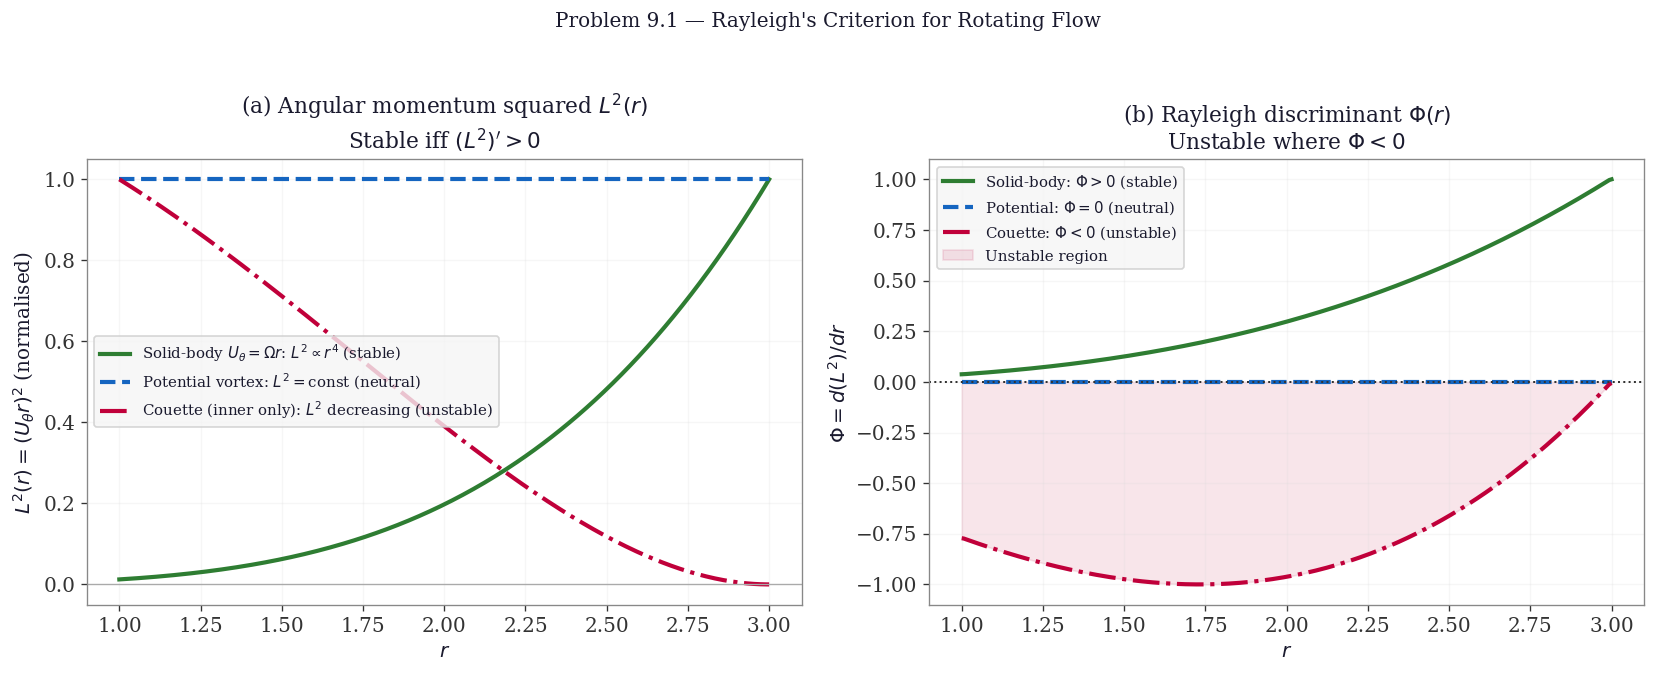

Saved: fig_9_1_rayleigh_criterion.png


In [2]:
r = np.linspace(1, 3, 300)

a_c, b_c, Om1 = 1.0, 3.0, 1.0
A_c = -Om1*a_c**2/(b_c**2-a_c**2)
B_c =  Om1*a_c**2*b_c**2/(b_c**2-a_c**2)

L2_solid   = r**4
L2_pot     = np.ones_like(r)
L2_couette = (A_c*r**2+B_c)**2

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5), facecolor=BG)

ax = axes[0]
ax.plot(r, L2_solid/L2_solid.max(),    color=GREEN, lw=2.5,
        label=r'Solid-body $U_\theta=\Omega r$: $L^2\propto r^4$ (stable)')
ax.plot(r, L2_pot,                     color=BLUE,  lw=2.5, ls='--',
        label=r'Potential vortex: $L^2=$const (neutral)')
ax.plot(r, L2_couette/abs(L2_couette).max(), color=RED, lw=2.5, ls='-.',
        label=r'Couette (inner only): $L^2$ decreasing (unstable)')
ax.axhline(0, color='#aaaaaa', lw=0.8)
ax.set_xlabel('$r$')
ax.set_ylabel(r'$L^2(r)=(U_\theta r)^2$ (normalised)')
ax.set_title("(a) Angular momentum squared $L^2(r)$\n"
             r"Stable iff $(L^2)'>0$", color='#1a1a2e')
ax.legend(fontsize=9, facecolor='#f5f5f5', loc='center left')
ax.grid(True, alpha=0.25)

ax = axes[1]
Phi_solid   = np.gradient(L2_solid,   r)
Phi_pot     = np.gradient(L2_pot,     r)
Phi_couette = np.gradient(L2_couette, r)

ax.plot(r, Phi_solid/abs(Phi_solid).max(),     color=GREEN, lw=2.5,
        label=r'Solid-body: $\Phi>0$ (stable)')
ax.plot(r, Phi_pot,                            color=BLUE,  lw=2.5, ls='--',
        label=r'Potential: $\Phi=0$ (neutral)')
ax.plot(r, Phi_couette/abs(Phi_couette).max(), color=RED,   lw=2.5, ls='-.',
        label=r'Couette: $\Phi<0$ (unstable)')
ax.axhline(0, color='#333333', lw=1.2, ls=':')
ax.fill_between(r, Phi_couette/abs(Phi_couette).max(), 0,
                where=Phi_couette<0, alpha=0.10, color=RED,
                label='Unstable region')
ax.set_xlabel('$r$')
ax.set_ylabel(r"$\Phi = d(L^2)/dr$")
ax.set_title("(b) Rayleigh discriminant $\\Phi(r)$\n"
             r"Unstable where $\Phi<0$", color='#1a1a2e')
ax.legend(fontsize=9, facecolor='#f5f5f5', loc='upper left')
ax.grid(True, alpha=0.25)

fig.suptitle("Problem 9.1 — Rayleigh's Criterion for Rotating Flow",
             color='#1a1a2e', fontsize=12, y=1.02)
fig.tight_layout(pad=1.2)
fig.savefig(FIG_DIR/'fig_9_1_rayleigh_criterion.png', bbox_inches='tight', facecolor=BG)
plt.show(); print('Saved: fig_9_1_rayleigh_criterion.png')


---
## Problem 9.5 — Landau Equation: $|A|^2(t)$

$d|A|^2/dt=\sigma|A|^2-l|A|^4$, $\sigma=\beta(R-R_c)$.  
Left: $l>0$ (supercritical) — saturation to $\sigma/l$.  
Right: $l<0$ (subcritical) — blow-up vs decay depending on $A_0$.


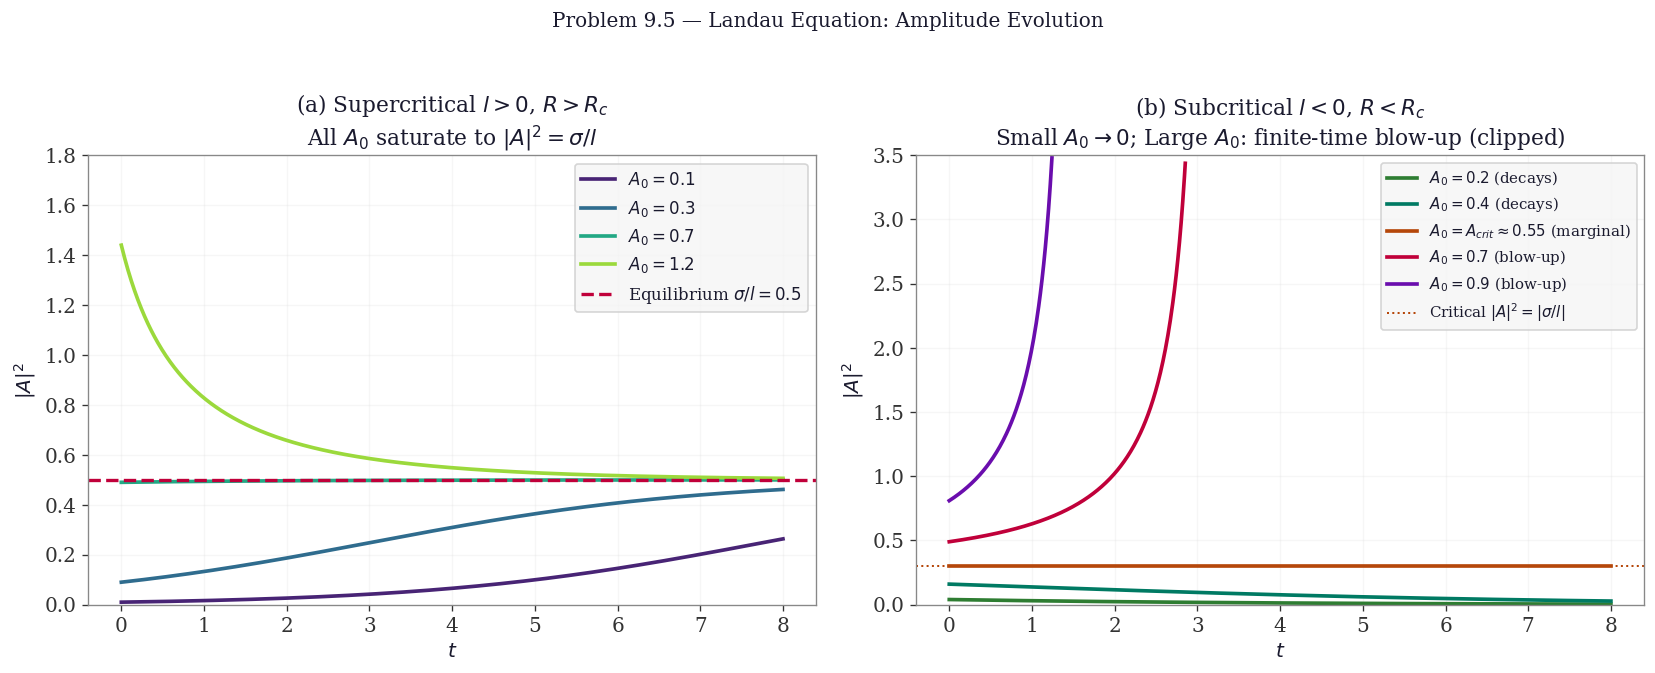

Saved: fig_9_5_landau.png


In [3]:
def landau_exact(t_arr, A0, sigma, l):
    B0 = A0**2
    if abs(sigma) < 1e-14:
        return B0 / (1 + l*B0*t_arr)
    C0 = 1.0/B0
    l_sig = l/sigma
    C = l_sig + (C0 - l_sig)*np.exp(-sigma*t_arr)
    with np.errstate(divide='ignore', invalid='ignore'):
        result = np.where(np.abs(C) > 1e-12, 1.0/C, np.nan)
    return result

t = np.linspace(0, 8, 800)
CLIP = 3.5   # clip blow-up at this value for display

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5), facecolor=BG)

# ── Left: l>0 supercritical ──────────────────────────────────────
ax = axes[0]
l_sup, sigma_sup = 1.0, 0.5
A0_vals = [0.1, 0.3, 0.7, 1.2]
colors_A = plt.cm.viridis(np.linspace(0.1, 0.85, len(A0_vals)))

for A0, col in zip(A0_vals, colors_A):
    B = landau_exact(t, A0, sigma_sup, l_sup)
    ax.plot(t, B, color=col, lw=2.2, label=f'$A_0={A0}$')

B_eq = sigma_sup/l_sup
ax.axhline(B_eq, color=RED, lw=2.0, ls='--',
           label=f'Equilibrium $\\sigma/l={B_eq:.1f}$')
ax.set_xlabel('$t$'); ax.set_ylabel('$|A|^2$')
ax.set_title('(a) Supercritical $l>0$, $R>R_c$\n'
             r'All $A_0$ saturate to $|A|^2=\sigma/l$',
             color='#1a1a2e')
ax.legend(fontsize=10, facecolor='#f5f5f5', loc='upper right')
ax.set_ylim(0, 1.8); ax.grid(True, alpha=0.25)

# ── Right: l<0 subcritical ────────────────────────────────────────
ax = axes[1]
l_sub, sigma_sub = -1.0, -0.3
A0_crit = np.sqrt(abs(sigma_sub)/abs(l_sub))   # = sqrt(0.3) ≈ 0.548

cases_sub = [
    (0.2,    GREEN,  '$A_0=0.2$ (decays)'),
    (0.4,    TEAL,   '$A_0=0.4$ (decays)'),
    (A0_crit,ORANGE, f'$A_0=A_{{crit}}\\approx{A0_crit:.2f}$ (marginal)'),
    (0.7,    RED,    '$A_0=0.7$ (blow-up)'),
    (0.9,    MAUVE,  '$A_0=0.9$ (blow-up)'),
]

for A0, col, lbl in cases_sub:
    B = landau_exact(t, A0, sigma_sub, l_sub)
    # Clip at CLIP for display
    B_plot = np.where(np.isfinite(B) & (B < CLIP), B, np.nan)
    ax.plot(t, B_plot, color=col, lw=2.2, label=lbl)

ax.axhline(A0_crit**2, color=ORANGE, lw=1.2, ls=':',
           label=r'Critical $|A|^2=|\sigma/l|$')
ax.set_xlabel('$t$'); ax.set_ylabel('$|A|^2$')
ax.set_title('(b) Subcritical $l<0$, $R<R_c$\n'
             r'Small $A_0\to0$; Large $A_0$: finite-time blow-up (clipped)',
             color='#1a1a2e')
ax.legend(fontsize=9, facecolor='#f5f5f5', loc='upper right')
ax.set_ylim(0, CLIP); ax.grid(True, alpha=0.25)

fig.suptitle('Problem 9.5 — Landau Equation: Amplitude Evolution',
             color='#1a1a2e', fontsize=12, y=1.02)
fig.tight_layout(pad=1.2)
fig.savefig(FIG_DIR/'fig_9_5_landau.png', bbox_inches='tight', facecolor=BG)
plt.show(); print('Saved: fig_9_5_landau.png')


---
## Problem 9.6 — Logistic Map: Bifurcation Diagram

$x_{n+1}=\lambda x_n(1-x_n)$: fixed point stability, period-2 orbit, period-doubling cascade.  
Left: bifurcation diagram. Right: orbit diagram for specific $\lambda$ values.


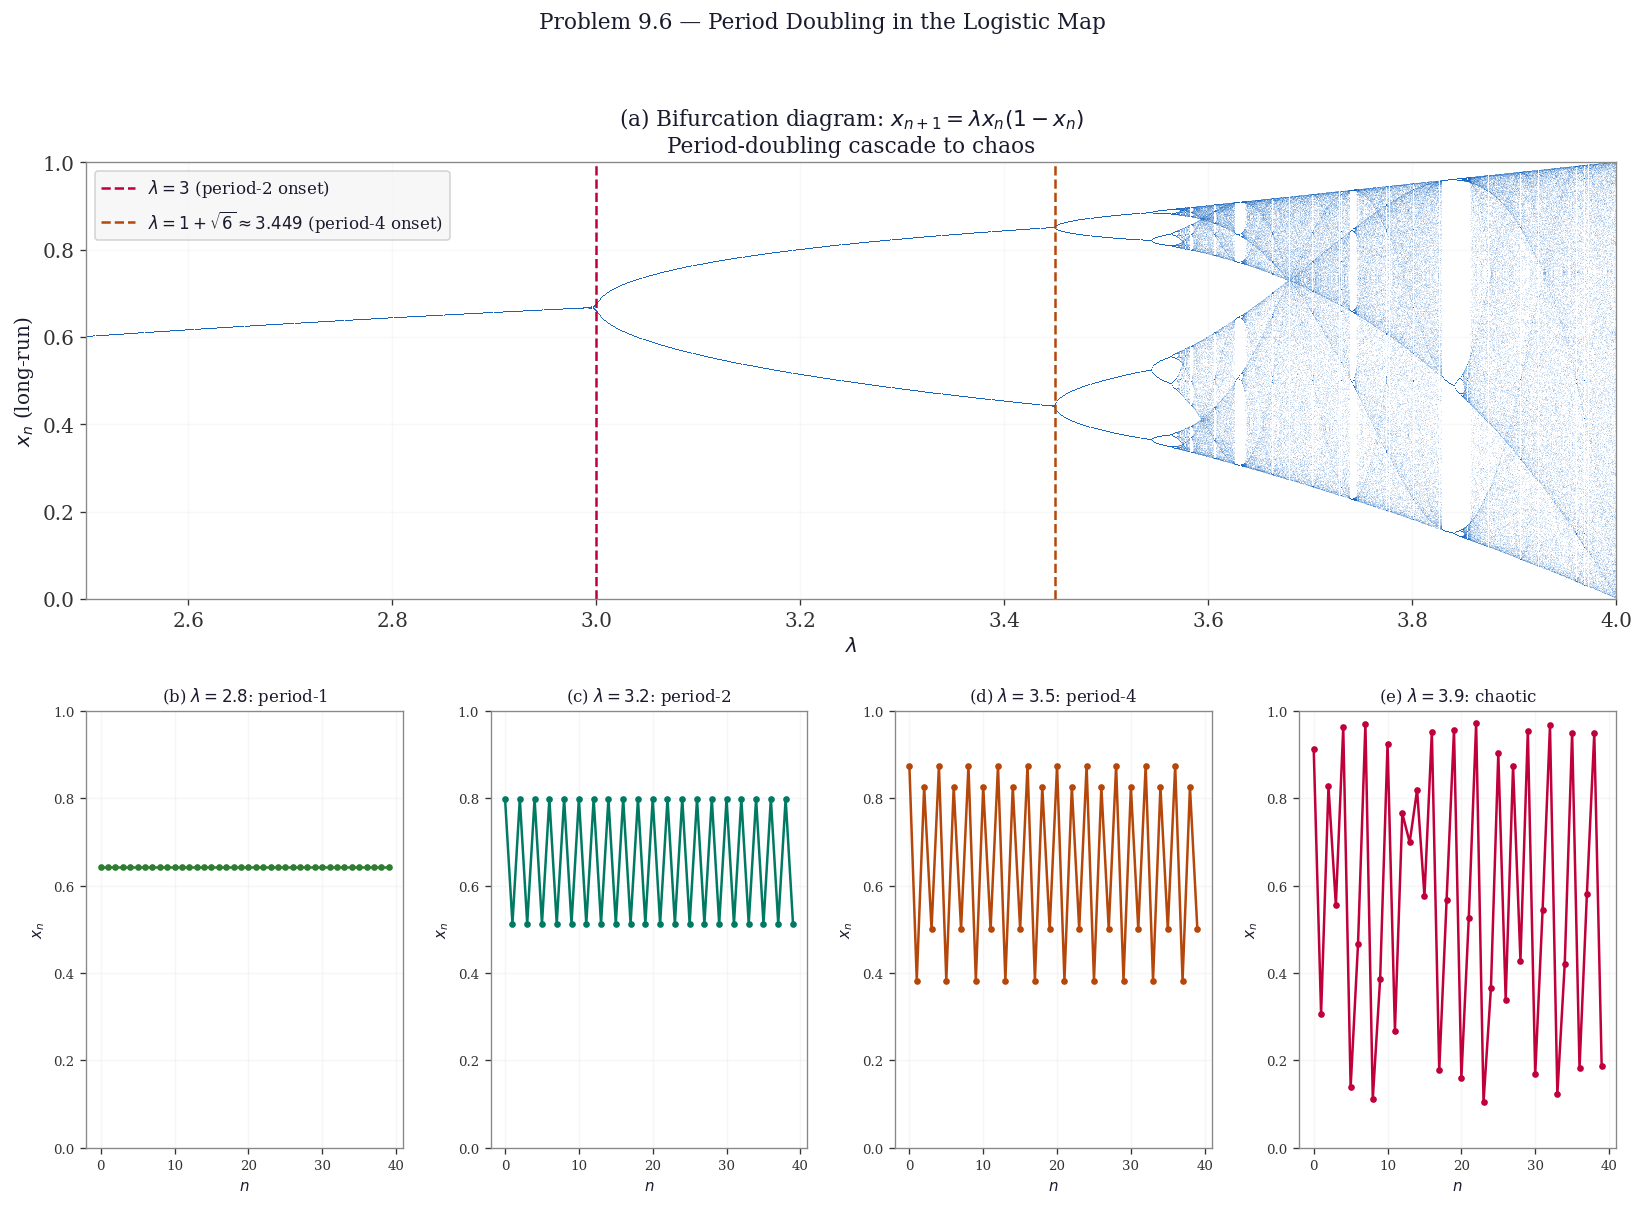

Saved: fig_9_6_logistic.png


In [4]:
# ── Bifurcation diagram ──────────────────────────────────────────
lam_arr = np.linspace(2.5, 4.0, 1500)
n_transient, n_keep = 500, 300

bif_lam, bif_x = [], []
for lam in lam_arr:
    x = 0.5
    for _ in range(n_transient):
        x = lam*x*(1-x)
    for _ in range(n_keep):
        x = lam*x*(1-x)
        bif_lam.append(lam)
        bif_x.append(x)

fig = plt.figure(figsize=(14, 10), facecolor=BG)

# Bifurcation diagram — full width top
ax_bif = fig.add_subplot(2, 1, 1)
ax_bif.plot(bif_lam, bif_x, ',', color=BLUE, alpha=0.15, markersize=0.4)
ax_bif.axvline(3.0,          color=RED,    lw=1.5, ls='--',
               label=r'$\lambda=3$ (period-2 onset)')
ax_bif.axvline(1+np.sqrt(6), color=ORANGE, lw=1.5, ls='--',
               label=r'$\lambda=1+\sqrt{6}\approx3.449$ (period-4 onset)')
ax_bif.set_xlabel(r'$\lambda$'); ax_bif.set_ylabel('$x_n$ (long-run)')
ax_bif.set_title('(a) Bifurcation diagram: $x_{{n+1}}=\\lambda x_n(1-x_n)$\n'
                 'Period-doubling cascade to chaos', color='#1a1a2e')
ax_bif.legend(fontsize=10, facecolor='#f5f5f5', loc='upper left')
ax_bif.set_xlim(2.5, 4.0); ax_bif.set_ylim(0, 1)
ax_bif.grid(True, alpha=0.2)

# Four separate orbit panels — bottom row
lam_cases  = [2.8, 3.2, 3.5, 3.9]
titles_lam = ['(b) $\\lambda=2.8$: period-1',
              '(c) $\\lambda=3.2$: period-2',
              '(d) $\\lambda=3.5$: period-4',
              '(e) $\\lambda=3.9$: chaotic']
colors_lam = [GREEN, TEAL, ORANGE, RED]
n_show = 40

for k, (lam_c, col, ttl) in enumerate(zip(lam_cases, colors_lam, titles_lam)):
    ax = fig.add_subplot(2, 4, 5+k)
    x = 0.5
    for _ in range(300): x = lam_c*x*(1-x)
    xs = []
    for _ in range(n_show):
        x = lam_c*x*(1-x)
        xs.append(x)
    ax.plot(range(n_show), xs, 'o-', color=col, lw=1.5, ms=3)
    ax.set_title(ttl, color='#1a1a2e', fontsize=10)
    ax.set_xlabel('$n$', fontsize=9)
    ax.set_ylabel('$x_n$', fontsize=9)
    ax.set_ylim(0, 1); ax.grid(True, alpha=0.25)
    ax.tick_params(labelsize=8)

fig.suptitle('Problem 9.6 — Period Doubling in the Logistic Map',
             color='#1a1a2e', fontsize=13, y=1.01)
fig.tight_layout(pad=1.5)
fig.savefig(FIG_DIR/'fig_9_6_logistic.png', bbox_inches='tight', facecolor=BG)
plt.show(); print('Saved: fig_9_6_logistic.png')


---
## Physics Validation Checks


In [5]:
print('=== Physics Validation Checks ===')

# 9.1: Rayleigh criterion — solid-body L^2 increasing, potential L^2 constant
r_v = np.linspace(1, 3, 100)
L2_sb  = r_v**4            # solid-body: always dL^2/dr > 0
L2_pv  = np.ones_like(r_v) # potential: dL^2/dr = 0
dL2_sb = np.gradient(L2_sb, r_v)
dL2_pv = np.gradient(L2_pv, r_v)
assert np.all(dL2_sb > 0), 'Solid-body not stable!'
assert np.allclose(dL2_pv, 0, atol=1e-10), 'Potential vortex not neutral!'
print('9.1  PASS: solid-body stable, potential vortex neutral')

# 9.5: Landau supercritical equilibrium
sigma_v, l_v = 0.5, 1.0
A0_v = 0.3
t_long = np.array([100.0])
B_long = landau_exact(t_long, A0_v, sigma_v, l_v)[0]
B_eq_v = sigma_v/l_v
assert abs(B_long - B_eq_v) < 1e-6
print(f'9.5  PASS: |A|^2(t->inf) = {B_long:.6f} = sigma/l = {B_eq_v:.6f}')

# 9.6: Fixed point x*=1-1/lambda stability boundary at lambda=3
for lam_t, stable in [(2.5, True), (3.5, False)]:
    fp = 1 - 1/lam_t
    df = lam_t*(1-2*fp)   # = 2 - lam_t
    is_stable = abs(df) < 1
    assert is_stable == stable, f'lambda={lam_t}: stability wrong'
print('9.6  PASS: x* stable for lambda<3, unstable for lambda>3')

# 9.6: Period-2 stability boundary at lambda = 1+sqrt(6)
lam_crit = 1 + np.sqrt(6)
# At lam_crit, |f'(X0)*f'(X1)| = 1 exactly
lam_t = lam_crit
# Period-2 points
disc = (1 - 1/lam_t)**2 - 4/lam_t**2
X0 = (1 + 1/lam_t + disc**0.5)/2
X1 = (1 + 1/lam_t - disc**0.5)/2
prod = abs(lam_t*(1-2*X0) * lam_t*(1-2*X1))
assert abs(prod - 1.0) < 1e-8, f'|f\'f\'|={prod} not 1 at lambda_crit'
print(f'9.6  PASS: |f\'.f\'|={prod:.6f}=1 at lambda=1+sqrt(6)={lam_crit:.4f}')

print('\nAll checks passed!')

=== Physics Validation Checks ===
9.1  PASS: solid-body stable, potential vortex neutral
9.5  PASS: |A|^2(t->inf) = 0.500000 = sigma/l = 0.500000
9.6  PASS: x* stable for lambda<3, unstable for lambda>3
9.6  PASS: |f'.f'|=1.000000=1 at lambda=1+sqrt(6)=3.4495

All checks passed!


---
## Package & Download Figures

Run after all figure cells to download `ch09_figures.zip`.


In [6]:
import zipfile
zip_path = Path('ch09_figures.zip')
fig_files = [
    'fig_9_1_rayleigh_criterion.png',
    'fig_9_5_landau.png',
    'fig_9_6_logistic.png',
]
with zipfile.ZipFile(zip_path, 'w', zipfile.ZIP_DEFLATED) as zf:
    for fname in fig_files:
        fpath = FIG_DIR / fname
        if fpath.exists():
            zf.write(fpath, fname)
            print(f'  added: {fname}  ({fpath.stat().st_size/1024:.0f} KB)')
        else:
            print(f'  MISSING: {fname}')
print(f'\nZip: {zip_path}  ({zip_path.stat().st_size/1024:.0f} KB)')
try:
    from google.colab import files
    files.download(str(zip_path)); print('Download started.')
except ImportError:
    print(f'Not in Colab — saved at: {zip_path.resolve()}')

  added: fig_9_1_rayleigh_criterion.png  (134 KB)
  added: fig_9_5_landau.png  (112 KB)
  added: fig_9_6_logistic.png  (280 KB)

Zip: ch09_figures.zip  (494 KB)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Download started.
